# Matplotlib 4 – Balkendiagramm und Histogramm
### Unterrichtsmaterial | Julia Brutskaya

Neulich hast du Balkendiagramme und Histogramme von Hand gezeichnet. Jetzt zeichnet der Computer. Dafür lernst du **Matplotlib** kennen, die Standardbibliothek für Diagramme in Python.

| Block | Thema |
|---|---|
| A | Matplotlib kennenlernen |
| B | Das Balkendiagramm |
| C | Zwei Merkmale in einem Diagramm |
| D | Das Histogramm |
| E | Form lesen, gestalten, speichern |
| F | Weitere Übungen und Zusatzblock Getter & Setter |

---

# Block A – Matplotlib kennenlernen

## 1 – Ein Bild statt zwanzig Zahlen
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Diagramme sind Dekoration für Präsentationen. Wer es genau wissen will, schaut in die Tabelle.“</td></tr></table>

Heute Vormittag hast du gesehen: Ein Diagramm zeigt auf einen Blick, was am häufigsten ist, wo die meisten Werte liegen und was aus der Reihe fällt. Genaue Werte liest man in der Tabelle. Beides ergänzt sich.

Wir arbeiten weiter mit der Kurs-Umfrage der **Datenwald-Akademie**. Die Farben sind dieselben wie im Skript, damit du die Diagramme wiedererkennst.

Matplotlib importiert man immer als `plt`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

zeilen = [
    (101, "Vormittag", "Kaffee", "M", 0, 25), (102, "Abend", "Tee", "S", 1, 35),
    (103, "Vormittag", "Mate", "L", 0, 18), (104, "Vormittag", "Kaffee", "L", 2, 42),
    (105, "Abend", "Wasser", "M", 0, 30), (106, "Vormittag", "Tee", "M", 1, 28),
    (107, "Abend", "Kaffee", "XL", 0, 55), (108, "Vormittag", "Kaffee", "S", 3, 12),
    (109, "Vormittag", "Mate", "M", 1, 38), (110, "Abend", "Tee", "M", 0, 115),
    (111, "Vormittag", "Kaffee", "L", 0, 32), (112, "Abend", "Mate", "L", 2, 45),
    (113, "Vormittag", "Wasser", "S", 1, 22), (114, "Vormittag", "Kaffee", "M", 0, 35),
    (115, "Abend", "Tee", "L", 1, 48), (116, "Vormittag", "Tee", "M", 0, 30),
    (117, "Abend", "Kaffee", "M", 3, 65), (118, "Vormittag", "Mate", "XL", 1, 40),
    (119, "Abend", "Wasser", "S", 0, 52), (120, "Vormittag", "Kaffee", "L", 2, 25),
]
spalten = ["teilnehmer_id", "kurszeit", "getraenk", "tshirt", "haustiere", "anfahrt_min"]
umfrage = pd.DataFrame(zeilen, columns=spalten)
umfrage["tshirt"] = pd.Categorical(umfrage["tshirt"], categories=["S", "M", "L", "XL"], ordered=True)
anfahrt = umfrage["anfahrt_min"]

# Farben wie im Skript
BLAU, ORANGE = "#2a78d6", "#eb6834"
GETRAENK_FARBEN = {"Kaffee": "#2a78d6", "Tee": "#eb6834", "Mate": "#1baf7a", "Wasser": "#eda100"}

umfrage.head()

,teilnehmer_id,kurszeit,getraenk,tshirt,haustiere,anfahrt_min
0,101,Vormittag,Kaffee,M,0,25
1,102,Abend,Tee,S,1,35
2,103,Vormittag,Mate,L,0,18
3,104,Vormittag,Kaffee,L,2,42
4,105,Abend,Wasser,M,0,30


---
## 2 – Figure, Axes, Axis

Matplotlib denkt in Schichten. Stell dir ein Blatt Papier vor, auf das du ein Diagramm malst:

| Ebene | Matplotlib-Begriff | Bild |
|---|---|---|
| das ganze Blatt | **Figure** | die Leinwand |
| ein einzelnes Diagramm darauf | **Axes** | das Bild auf der Leinwand |
| die Zahlengeraden | **Axis** (x und y) | die Lineale am Rand |
| Balken, Titel, Beschriftungen, Legende | Artists | die Pinselstriche |

Eine Figure kann mehrere Axes enthalten, zum Beispiel zwei Diagramme nebeneinander.

> ⚠️ **Häufige Verwechslung:** `Axes` ≠ `Axis`.
> `Axes` ist das ganze Diagramm. `Axis` ist eine einzelne Achse.

---
## 3 – pyplot oder OOP?

Matplotlib bietet zwei Schreibweisen.

- **pyplot-Stil:** Alle Befehle beginnen mit `plt.`. Matplotlib merkt sich im Hintergrund, welches Diagramm gerade „dran“ ist. Das geht schnell, wird aber unübersichtlich, sobald es mehr als ein Diagramm gibt.
- **OOP-Stil** (objektorientiert): Du legst Figure und Axes ausdrücklich an und sagst jedem Befehl, in welches Diagramm er zeichnet.

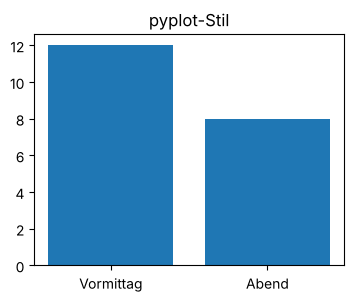

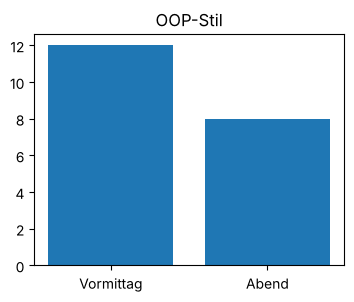

In [ ]:
kurszeit = umfrage["kurszeit"].value_counts()

# pyplot-Stil
plt.figure(figsize=(4, 3))
plt.bar(kurszeit.index, kurszeit.values)
plt.title("pyplot-Stil")
plt.show()

# OOP-Stil (ab jetzt nur noch so)
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(kurszeit.index, kurszeit.values)
ax.set_title("OOP-Stil")
plt.show()

Beide Bilder sind gleich. **Ab jetzt arbeiten wir nur noch im OOP-Stil.** Du weißt immer, in welches Diagramm du zeichnest, und für zwei Diagramme nebeneinander geht es gar nicht anders.

Im OOP-Stil heißen viele Befehle `ax.set_…`, zum Beispiel `ax.set_title()`. Zu fast jedem gibt es ein Gegenstück `ax.get_…`, das den Wert ausliest. Mehr dazu im Zusatzblock in Abschnitt 19.

---
## 4 – Das Grundgerüst

Jedes Diagramm entsteht in denselben vier Schritten:

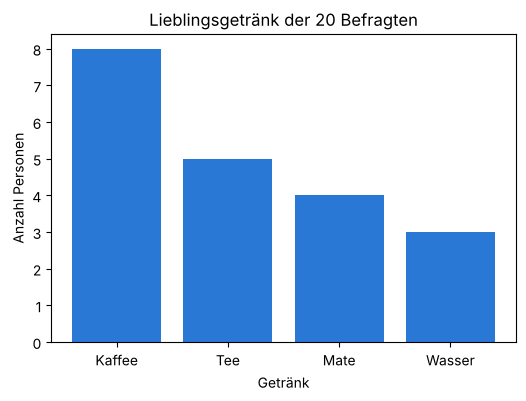

In [ ]:
anzahl = umfrage["getraenk"].value_counts()           # Häufigkeiten wie an Tag 1

fig, ax = plt.subplots(figsize=(6, 4))                # 1. Figure und Axes anlegen
ax.bar(anzahl.index, anzahl.values, color=BLAU)       # 2. zeichnen
ax.set_title("Lieblingsgetränk der 20 Befragten")     # 3. beschriften
ax.set_xlabel("Getränk")
ax.set_ylabel("Anzahl Personen")
plt.show()                                            # 4. anzeigen

| Schritt | Befehl | Bedeutung |
|---|---|---|
| 1 | `fig, ax = plt.subplots(figsize=(6, 4))` | Leinwand (6 × 4 Zoll) und ein Diagramm darauf |
| 2 | `ax.bar(x, hoehe, color=...)` | Balken zeichnen |
| 3 | `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()` | Titel und Achsen beschriften |
| 4 | `plt.show()` | Diagramm anzeigen |

### Übung 1

Zeichne, wie viele Personen den Vormittags- und wie viele den Abendkurs besuchen.

- **a)** Zähle die Kurszeiten mit `value_counts()`.
- **b)** Zeichne ein Balkendiagramm in Blau. Titel: „Teilnehmende nach Kurszeit“, y-Achse: „Anzahl Personen“.
- **c)** Ändere `figsize` auf `(3, 4)` und dann auf `(8, 2)`. Was ändert sich, was bleibt gleich?

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c)

# Block B – Das Balkendiagramm

## 5 – Das Balkendiagramm genauer
<table><tr><td width="160"><img src="png%20Dateien/etta_elster.png" alt="Etta" width="150"></td><td><b>Etta sagt:</b><br><br>„Sorten bekommen einzelne Balken mit Abstand dazwischen. Das Balkendiagramm ist meins.“</td></tr></table>

`ax.bar(x, hoehe)` braucht zwei Dinge:

- `x`: die Ausprägungen, also die Namen der Balken. Aus `value_counts()` ist das `.index`.
- `hoehe`: die Häufigkeiten. Aus `value_counts()` ist das `.values`.

Die Lücken zwischen den Balken macht Matplotlib von selbst. Der Parameter `width` steht auf 0,8, die Balken füllen also 80 % ihres Platzes. Lass die Lücken drin: Sie zeigen, dass zwischen Kaffee und Tee nichts liegt.

**Anzahl oder Anteil?** Mit `normalize=True` liefert `value_counts()` Anteile. Die Form des Diagramms bleibt gleich, nur die Achse ändert sich.

getraenk
Kaffee    40.0
Tee       25.0
Mate      20.0
Wasser    15.0
Name: proportion, dtype: float64


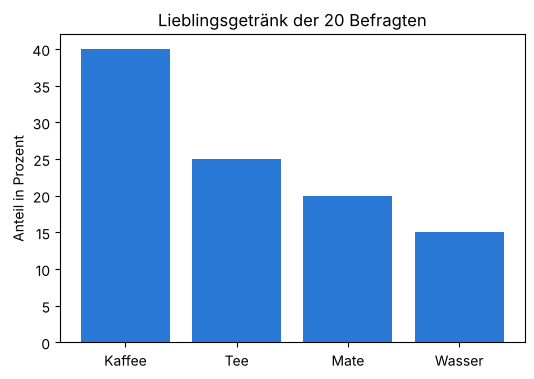

In [ ]:
anteil = umfrage["getraenk"].value_counts(normalize=True) * 100
print(anteil)                                         # Kaffee 40, Tee 25, Mate 20, Wasser 15

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(anteil.index, anteil.values, color=BLAU)
ax.set_title("Lieblingsgetränk der 20 Befragten")
ax.set_ylabel("Anteil in Prozent")
plt.show()

---
## 6 – Die richtige Reihenfolge
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Ich sortiere die Balken alphabetisch. Das ist ordentlich.“</td></tr></table>

`sort_index()` sortiert nach den Namen, also alphabetisch:

['Kaffee', 'Mate', 'Tee', 'Wasser']


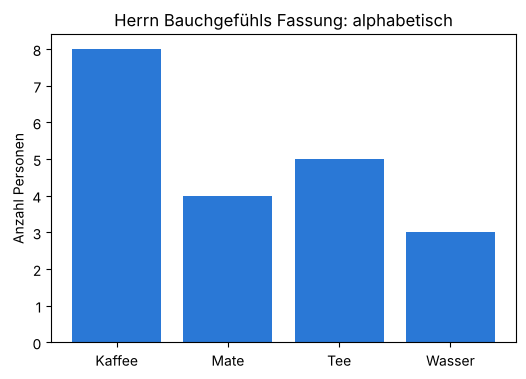

In [ ]:
alphabetisch = anzahl.sort_index()
print(alphabetisch.index.tolist())                    # ['Kaffee', 'Mate', 'Tee', 'Wasser']

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(alphabetisch.index, alphabetisch.values, color=BLAU)
ax.set_title("Herrn Bauchgefühls Fassung: alphabetisch")
ax.set_ylabel("Anzahl Personen")
plt.show()

<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Mate vor Tee, nur weil M vor T kommt. Das war wirklich keine gute Ordnung.“</td></tr></table>

**Nominale Merkmale** haben keine natürliche Reihenfolge. Dort sortiert man nach Häufigkeit. `value_counts()` macht das schon von selbst, deshalb war das Diagramm in Abschnitt 4 richtig.

**Ordinale Merkmale** haben eine feste Reihenfolge. Bei den T-Shirt-Größen schadet `value_counts()`: Es sortiert nach Häufigkeit, und S landet zwischen L und XL.

['M', 'L', 'S', 'XL']
['S', 'M', 'L', 'XL'] [4, 8, 6, 2]


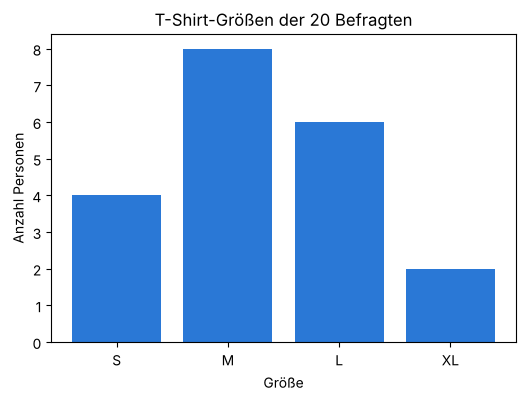

In [ ]:
print(umfrage["tshirt"].value_counts().index.tolist())                 # ['M', 'L', 'S', 'XL'] – falsch
groessen = umfrage["tshirt"].value_counts().sort_index()
print(groessen.index.tolist(), groessen.values.tolist())               # ['S', 'M', 'L', 'XL'] [4, 8, 6, 2]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(groessen.index, groessen.values, color=BLAU)
ax.set_title("T-Shirt-Größen der 20 Befragten")
ax.set_xlabel("Größe")
ax.set_ylabel("Anzahl Personen")
plt.show()

Weil `tshirt` eine geordnete Kategorie ist (`pd.Categorical` mit `ordered=True`), sortiert `sort_index()` nach S, M, L, XL und nicht nach dem Alphabet.

Dasselbe gilt für **gezählte Merkmale mit wenigen Werten**, etwa die Anzahl der Haustiere: Die Reihenfolge 0, 1, 2, 3 bleibt.

[0, 1, 2, 3] [9, 6, 3, 2]


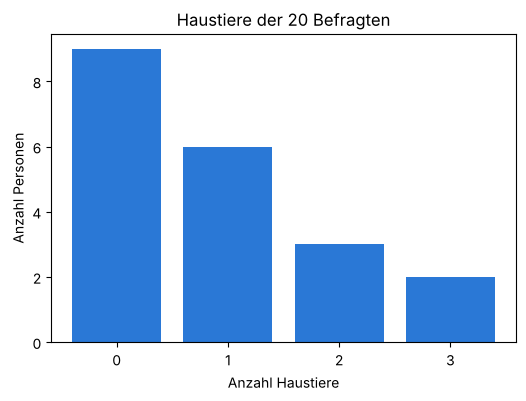

In [ ]:
haustiere = umfrage["haustiere"].value_counts().sort_index()
print(haustiere.index.tolist(), haustiere.values.tolist())             # [0, 1, 2, 3] [9, 6, 3, 2]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(haustiere.index, haustiere.values, color=BLAU)
ax.set_xticks(haustiere.index)          # nur 0, 1, 2, 3 an die Achse, keine 0.5-Schritte
ax.set_title("Haustiere der 20 Befragten")
ax.set_xlabel("Anzahl Haustiere")
ax.set_ylabel("Anzahl Personen")
plt.show()

| Merkmal | Reihenfolge | Befehl |
|---|---|---|
| nominal (Getränk) | nach Häufigkeit | `value_counts()` |
| ordinal (T-Shirt) | natürliche Reihenfolge | `value_counts().sort_index()` |
| gezählt, wenige Werte (Haustiere) | Zahlenreihenfolge | `value_counts().sort_index()` |

---
## 7 – Die Achse beginnt bei null
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Seht her: Kaffee ist doppelt so beliebt wie Tee und sechsmal so beliebt wie Wasser!“</td></tr></table>

Um seinen Trick zu zeigen, stellen wir zwei Diagramme nebeneinander. `plt.subplots(1, 2)` legt eine Figure mit **zwei Axes nebeneinander** an. Die geben wir gleich zwei Namen: `links` und `rechts`. Wie man größere Raster baut, kommt morgen.

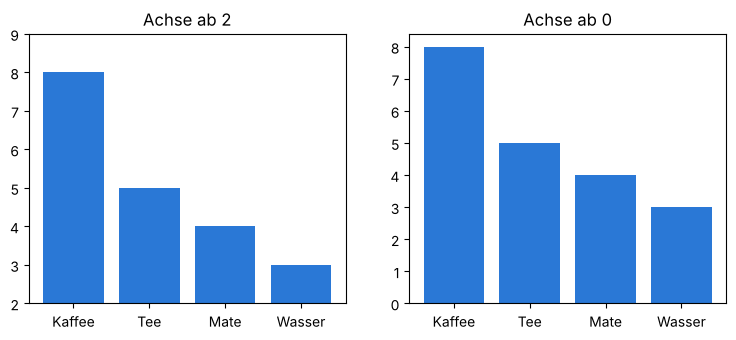

Kaffee / Tee:    1.6
Kaffee / Wasser: 2.67
sichtbar links:  {'Kaffee': 6, 'Tee': 3, 'Mate': 2, 'Wasser': 1}


In [ ]:
fig, (links, rechts) = plt.subplots(1, 2, figsize=(9, 3.5))

links.bar(anzahl.index, anzahl.values, color=BLAU)
links.set_ylim(2, 9)                                  # Herrn Bauchgefühls Trick
links.set_title("Achse ab 2")

rechts.bar(anzahl.index, anzahl.values, color=BLAU)
rechts.set_title("Achse ab 0")

plt.show()

# Nachrechnen
print("Kaffee / Tee:   ", anzahl["Kaffee"] / anzahl["Tee"])            # 1.6
print("Kaffee / Wasser:", round(anzahl["Kaffee"] / anzahl["Wasser"], 2))  # 2.67
# Was man links sieht: von jedem Balken fehlen unten 2
print("sichtbar links: ", (anzahl - 2).to_dict())                      # Kaffee 6, Tee 3, Wasser 1

<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Aber so sah es viel eindrucksvoller aus.“</td></tr></table>

Genau das ist das Problem. Links sind die sichtbaren Balken 6, 3 und 1 lang. Daher kommen „doppelt“ und „sechsmal“. In Wahrheit ist Kaffee 1,6-mal so beliebt wie Tee und knapp 2,7-mal so beliebt wie Wasser.

> **Merke:** `ax.bar` beginnt von selbst bei null. Gefährlich wird es erst, wenn du mit `set_ylim` die untere Grenze verschiebst. Bei Balkendiagrammen: nicht tun.

---
## 8 – Balken quer legen und beschriften

Bei langen Namen dreht man das Diagramm: `ax.barh()` (h für horizontal). Die Namen stehen links, die Balken laufen nach rechts.

Zwei Kleinigkeiten:

- Bei `barh` steht der **erste** Balken **unten**. Damit der häufigste oben steht, dreht `ax.invert_yaxis()` die Reihenfolge um.
- `ax.bar_label(balken)` schreibt die Werte an die Balken. Dafür speicherst du das Ergebnis von `ax.barh(...)` in einer Variablen. (In älterem Material findest du dafür eine Schleife mit `ax.text`. `bar_label` macht dasselbe in einer Zeile.)

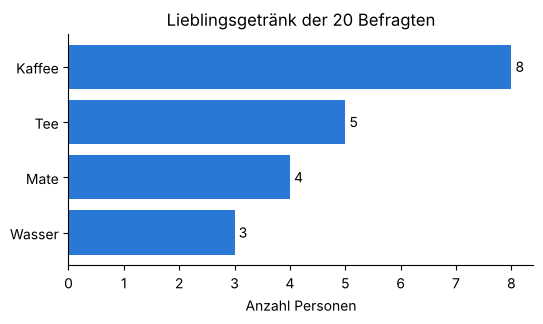

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
balken = ax.barh(anzahl.index, anzahl.values, color=BLAU)
ax.invert_yaxis()                                     # häufigster Balken oben
ax.bar_label(balken, padding=3)                       # Werte rechts an die Balken
ax.set_title("Lieblingsgetränk der 20 Befragten")
ax.set_xlabel("Anzahl Personen")
ax.spines[["top", "right"]].set_visible(False)        # oberen und rechten Rahmen entfernen
plt.show()

`ax.spines` sind die vier Rahmenlinien des Diagramms. Ohne den oberen und rechten Rahmen wirkt das Diagramm ruhiger.

### Übung 2

Am Vormittag hast du in Übung 3 Herrn Bauchgefühls T-Shirt-Diagramm untersucht. So hat er es gebaut: Größen nach Häufigkeit sortiert, y-Achse von 1 bis 9, ohne Titel und ohne Achsenbeschriftung.

- **a)** Baue sein Diagramm nach.
- **b)** Schreibe die drei Fehler als Kommentar in die Zelle.
- **c)** Repariere das Diagramm: richtige Reihenfolge, Achse ab 0, Titel und Achsenbeschriftungen.
- **d)** Schreibe mit `ax.bar_label()` die Werte über die Balken.

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c)

In [ ]:
# d)

# Block C – Zwei Merkmale in einem Diagramm

## 9 – Gruppiert
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Eine Kreuztabelle kann man nicht zeichnen. Viel zu viele Zahlen.“</td></tr></table>

Pandas kann selbst zeichnen. `DataFrame.plot.bar()` benutzt im Hintergrund Matplotlib:

- Jede **Zeile** der Kreuztabelle wird eine Gruppe auf der x-Achse.
- Jede **Spalte** bekommt eine eigene Farbe.
- Der Befehl gibt ein `Axes` zurück. Daran kannst du wie gewohnt `set_title` & Co. aufrufen. Die Figure dazu heißt `ax.figure`.

getraenk   Kaffee  Tee  Mate  Wasser
kurszeit                            
Vormittag       6    2     3       1
Abend           2    3     1       2


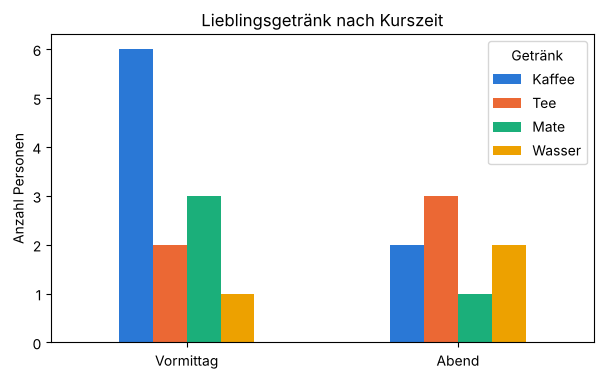

In [ ]:
reihenfolge = ["Kaffee", "Tee", "Mate", "Wasser"]
kreuz = pd.crosstab(umfrage["kurszeit"], umfrage["getraenk"]).loc[["Vormittag", "Abend"], reihenfolge]
print(kreuz)

farben = [GETRAENK_FARBEN[g] for g in reihenfolge]

ax = kreuz.plot.bar(color=farben, rot=0, figsize=(7, 4))   # rot=0: Beschriftung waagerecht
ax.set_title("Lieblingsgetränk nach Kurszeit")
ax.set_xlabel("")
ax.set_ylabel("Anzahl Personen")
ax.legend(title="Getränk")
plt.show()

Die absoluten Zahlen liest du gut ab. Zwischen den Kursen vergleichst du die Höhen aber nicht fair: Der Vormittagskurs hat 12 Personen, der Abendkurs 8.

---
## 10 – Gestapelt auf 100 %

Für den fairen Vergleich brauchst du die **Zeilenprozente**: `normalize="index"`. Jeder Kurs bekommt einen gleich langen Balken, aufgeteilt nach Anteilen.

getraenk   Kaffee   Tee  Mate  Wasser
kurszeit                             
Vormittag    50.0  16.7  25.0     8.3
Abend        25.0  37.5  12.5    25.0


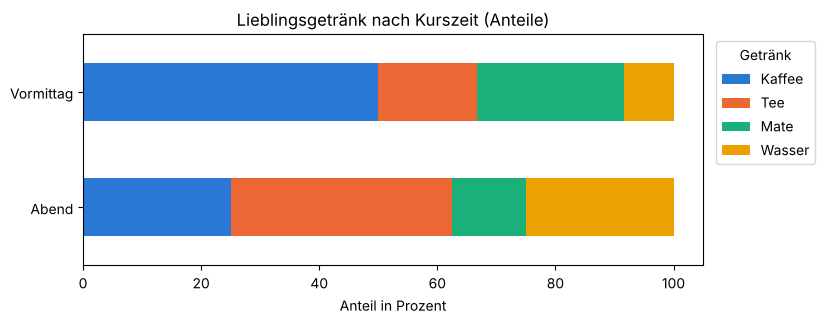

In [ ]:
anteile = pd.crosstab(umfrage["kurszeit"], umfrage["getraenk"], normalize="index").loc[["Vormittag", "Abend"], reihenfolge] * 100
print(anteile.round(1))

ax = anteile.plot.barh(stacked=True, color=farben, figsize=(8, 3))
ax.invert_yaxis()                                     # Vormittag oben
ax.set_title("Lieblingsgetränk nach Kurszeit (Anteile)")
ax.set_xlabel("Anteil in Prozent")
ax.set_ylabel("")
ax.legend(title="Getränk", loc="upper left", bbox_to_anchor=(1.01, 1))   # Legende rechts neben das Diagramm
plt.show()

<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Die Abendleute und ihr Tee. Jetzt sehe ich es sogar.“</td></tr></table>

Im Vormittagskurs macht Kaffee die Hälfte aus (50 %), im Abendkurs führt Tee (37,5 %).

| Diagramm | wofür | Befehl |
|---|---|---|
| gruppiert | absolute Zahlen ablesen | `kreuz.plot.bar(...)` |
| gestapelt auf 100 % | Anteile zwischen Gruppen vergleichen | `anteile.plot.barh(stacked=True, ...)` |

Sobald Farben eine Bedeutung haben, braucht das Diagramm eine **Legende**, und jede Farbe steht überall für dasselbe. Deshalb holen wir die Farben immer aus `GETRAENK_FARBEN`.

### Übung 3

Unterscheiden sich die T-Shirt-Größen zwischen Vormittags- und Abendkurs?

- **a)** Erstelle die Kreuztabelle Kurszeit × T-Shirt-Größe, Vormittag oben. In welcher Reihenfolge stehen die Größen, und warum?
- **b)** Zeichne sie als gruppiertes Balkendiagramm mit Titel, y-Beschriftung und Legende.
- **c)** Zeichne die Zeilenprozente als auf 100 % gestapeltes Balkendiagramm.
- **d)** Im Vormittagskurs tragen 5 Personen M, im Abendkurs nur 3. Tragen die Vormittagsleute also deutlich öfter M?

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c)

In [ ]:
# d)

# Block D – Das Histogramm

## 11 – Ein Balken pro Minutenwert?
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Für die Anfahrt mache ich einfach auch ein Balkendiagramm. Ein Balken pro Minutenwert.“</td></tr></table>

verschiedene Werte: 17


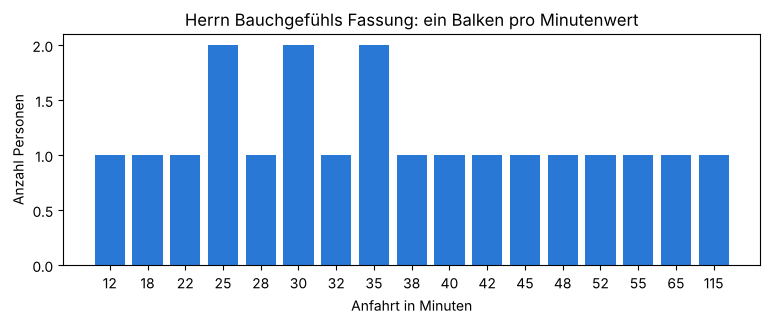

In [ ]:
werte = anfahrt.value_counts().sort_index()
print("verschiedene Werte:", len(werte))              # 17

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(werte.index.astype(str), werte.values, color=BLAU)   # als Text: ein Balken pro Wert, wie bei Sorten
ax.set_title("Herrn Bauchgefühls Fassung: ein Balken pro Minutenwert")
ax.set_xlabel("Anfahrt in Minuten")
ax.set_ylabel("Anzahl Personen")
plt.show()

Fast alle Balken sind gleich hoch, weil fast jeder Wert nur einmal vorkommt. Außerdem gehen die Abstände verloren: 65 und 115 stehen direkt nebeneinander, als lägen sie eine Minute auseinander.
<table><tr><td width="160"><img src="png%20Dateien/nils_eichhoernchen.png" alt="Nils" width="150"></td><td><b>Nils sagt:</b><br><br>„Messwerte gehören auf einen Zahlenstrahl. Erst in Klassen einteilen, dann zählen.“</td></tr></table>

---
## 12 – Das Histogramm mit `ax.hist`

`ax.hist()` bekommt die **Rohdaten** und zählt selbst. Mit `bins` gibst du die Klassengrenzen als Liste vor.

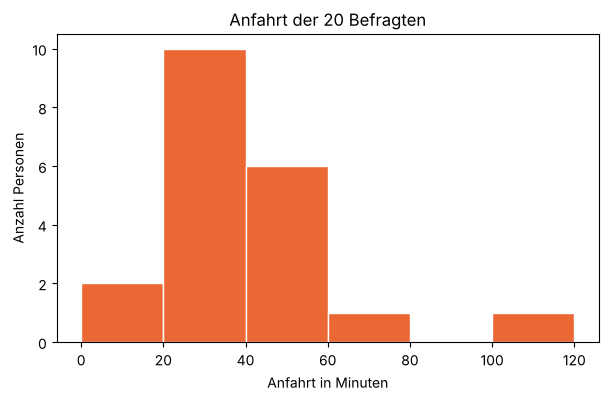

Anzahl je Klasse: [2, 10, 6, 1, 0, 1]
Grenzen:          [0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0]


In [ ]:
grenzen = list(range(0, 121, 20))                     # [0, 20, 40, 60, 80, 100, 120]

fig, ax = plt.subplots(figsize=(7, 4))
hoehen, kanten, balken = ax.hist(anfahrt, bins=grenzen, color=ORANGE, edgecolor="white")
ax.set_xticks(grenzen)                                # Klassengrenzen an die Achse
ax.set_title("Anfahrt der 20 Befragten")
ax.set_xlabel("Anfahrt in Minuten")
ax.set_ylabel("Anzahl Personen")
plt.show()

print("Anzahl je Klasse:", hoehen.astype(int).tolist())
print("Grenzen:         ", kanten.tolist())

| Teil | Bedeutung |
|---|---|
| `bins=grenzen` | die Klassengrenzen |
| `edgecolor="white"` | weiße Ränder, damit man die Klassen unterscheidet. Die Balken stoßen trotzdem aneinander. |
| `hoehen, kanten, balken = ...` | `ax.hist` gibt die gezählten Häufigkeiten und die Grenzen zurück |

**Stolperstein: `bins` als Zahl.** Mit `bins=6` legt Matplotlib die Grenzen zwischen Minimum und Maximum, nicht auf glatte Werte:

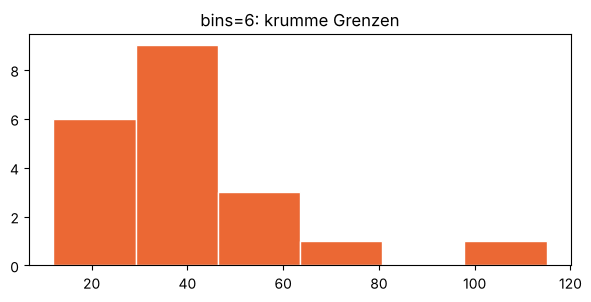

[12.0, 29.17, 46.33, 63.5, 80.67, 97.83, 115.0]


In [ ]:
fig, ax = plt.subplots(figsize=(7, 3))
hoehen6, kanten6, _ = ax.hist(anfahrt, bins=6, color=ORANGE, edgecolor="white")
ax.set_title("bins=6: krumme Grenzen")
plt.show()

print(kanten6.round(2).tolist())                      # von 12 bis 115 in Schritten von 17.17

Für Diagramme, die man lesen soll, gibst du die Grenzen immer als Liste vor.

---
## 13 – Werte genau auf der Grenze

Vergleiche mit dem Skript: Dort hatte die Klasse „über 20 bis 40“ **11** Personen. Bei `ax.hist` sind es nur **10**. Wer hat sich verzählt?

In [ ]:
# wie im Skript und wie pd.cut an Tag 1: über a bis einschließlich b
wie_skript = pd.cut(anfahrt, bins=grenzen).value_counts().sort_index()
print("Skript / pd.cut:", wie_skript.values.tolist())      # [2, 11, 5, 1, 0, 1]

# Matplotlib: von a bis unter b
print("ax.hist:        ", hoehen.astype(int).tolist())     # [2, 10, 6, 1, 0, 1]

Skript / pd.cut: [2, 11, 5, 1, 0, 1]
ax.hist:         [2, 10, 6, 1, 0, 1]


Niemand. Die Person mit **40 Minuten** liegt genau auf einer Grenze.

| Programm | Klasse | die 40 landet in |
|---|---|---|
| Skript, `pd.cut` | „über a bis b“ | über 20 bis 40 |
| `ax.hist` | „von a bis unter b“ | 40 bis unter 60 |

Das Skript hat es angekündigt: „Programme machen es oft andersherum.“ Gleiche Daten, gleiche Grenzen, und trotzdem ein anderes Bild.

**Das Skript-Histogramm genau nachbauen:** erst mit `pd.cut` zählen, dann mit `ax.bar` zeichnen. Damit die Balken wie im Histogramm aneinanderstoßen, setzt du `width` auf die Klassenbreite und `align="edge"`. Dann beginnt jeder Balken an seiner linken Grenze.

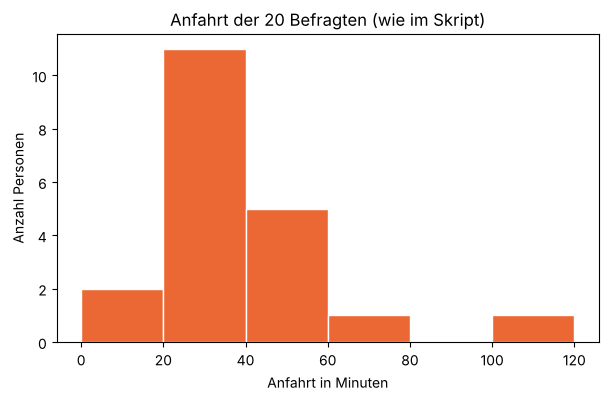

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(grenzen[:-1], wie_skript.values, width=20, align="edge", color=ORANGE, edgecolor="white")
ax.set_xticks(grenzen)
ax.set_title("Anfahrt der 20 Befragten (wie im Skript)")
ax.set_xlabel("Anfahrt in Minuten")
ax.set_ylabel("Anzahl Personen")
plt.show()

`grenzen[:-1]` sind alle Grenzen außer der letzten, also die linken Ränder 0, 20, …, 100.

> **Tipp für ganze Zahlen:** Legt man die Grenzen auf halbe Werte (z. B. 0,5 / 20,5 / 40,5 …), liegt kein Wert auf einer Grenze, und beide Zählweisen liefern dasselbe. Das probierst du in Block F mit den UK-Charts aus.
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Mein Diagramm hatte 17 Balken und sagte nichts. Seins hat sechs Klassen und zeigt alles.“</td></tr></table>

---
## 14 – Wie viele Klassen?
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Je mehr Klassen, desto genauer. Ich nehme 24.“</td></tr></table>

Drei Klassenbreiten nebeneinander: 40, 20 und 5 Minuten. Die Bilder zeichnet `ax.hist` („bis unter“), die Zahlen darunter sind wie im Skript gezählt. Deshalb steht die 40 im Bild eine Klasse weiter.

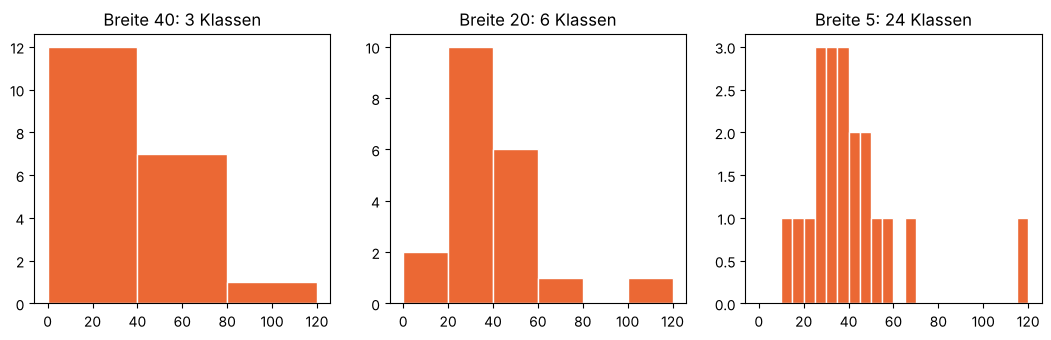

Breite 40: [13, 6, 1]  leer: 0 von 3
Breite 20: [2, 11, 5, 1, 0, 1]  leer: 1 von 6
Breite  5: [0, 0, 1, 1, 3, 3, 3, 2, 2, 1, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]  leer: 13 von 24
Faustregel: Wurzel aus n = 4.47


In [ ]:
fig, (links, mitte, rechts) = plt.subplots(1, 3, figsize=(13, 3.5))

links.hist(anfahrt, bins=range(0, 121, 40), color=ORANGE, edgecolor="white")
links.set_title("Breite 40: 3 Klassen")

mitte.hist(anfahrt, bins=range(0, 121, 20), color=ORANGE, edgecolor="white")
mitte.set_title("Breite 20: 6 Klassen")

rechts.hist(anfahrt, bins=range(0, 121, 5), color=ORANGE, edgecolor="white")
rechts.set_title("Breite 5: 24 Klassen")

plt.show()

# Gezählt wie im Skript
for breite in (40, 20, 5):
    zaehlung = pd.cut(anfahrt, bins=list(range(0, 121, breite))).value_counts().sort_index()
    print(f"Breite {breite:>2}: {zaehlung.values.tolist()}  leer: {(zaehlung == 0).sum()} von {len(zaehlung)}")

print("Faustregel: Wurzel aus n =", round(np.sqrt(len(anfahrt)), 2))   # 4.47

- **Zu grob (40):** Man sieht nur, dass die meisten unter 40 Minuten brauchen. Gipfel und Lücke verschwinden.
- **Zu fein (5):** Einzelne Balken der Höhe 1 bis 3, dazwischen viele leere Klassen. Keine Form.
- **Passend (20):** Die Faustregel sagt √20 ≈ 4,5, also rund fünf Klassen. Sechs Klassen mit der glatten Breite 20 passen dazu.
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„24 Klassen, und mehr als die Hälfte davon ist leer. Genauer ist das nicht geworden.“</td></tr></table>

### Übung 4

Die Prüfungspunkte aus Übung 5 vom Vormittag:

In [ ]:
punkte = pd.Series([71, 45, 88, 63, 52, 95, 66, 34, 78, 61, 58, 82, 70, 48, 75, 64, 85, 55, 68, 73])

- **a)** Zeichne das Histogramm mit den Klassengrenzen 0, 20, …, 100 in Orange, mit weißen Rändern, Titel und Achsenbeschriftungen.
- **b)** Gib die Anzahl je Klasse aus. Vergleiche mit deiner Handzählung vom Vormittag. Warum stimmen `ax.hist` und Handzählung hier überein?
- **c)** Welche Klasse ist die Modalklasse? Berechne Mittelwert und Median. Welche Form hat die Verteilung?
- **d)** Wie viele Klassen schlägt die Faustregel vor? Passt das zu deinem Diagramm?

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c)

In [ ]:
# d)

# Block E – Form lesen, gestalten, speichern

## 15 – Die Form lesen
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Ein Histogramm ist ein Histogramm. Was soll man da groß lesen?“</td></tr></table>

Zwei Lagemaße kennst du schon: Median und Mittelwert. Mit `ax.axvline(x)` zeichnest du eine senkrechte Linie an der Stelle `x`. Mit `label=` und `ax.legend()` bekommt sie eine Legende.

<table><tr>
<td align="center"><img src="png%20Dateien/drilling_median.png" alt="Drilling Median" width="110"><br>Median</td>
<td align="center"><img src="png%20Dateien/drilling_mittelwert.png" alt="Drilling Mittelwert" width="110"><br>Mittelwert</td>
</tr></table>

35.0 39.6


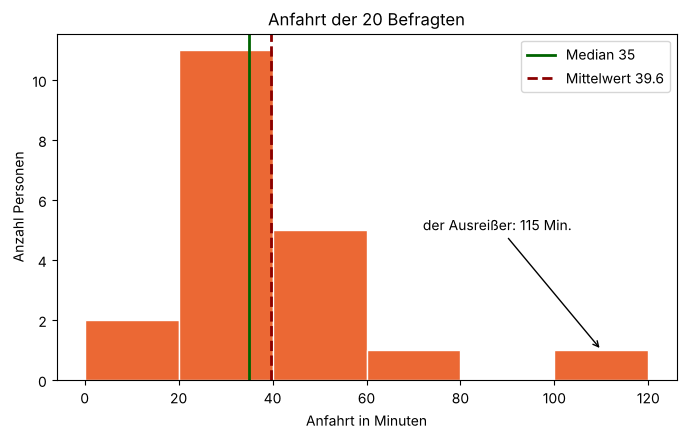

In [ ]:
median = anfahrt.median()
mittelwert = anfahrt.mean()
print(median, mittelwert)                             # 35.0 39.6

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(grenzen[:-1], wie_skript.values, width=20, align="edge", color=ORANGE, edgecolor="white")
ax.axvline(median, color="darkgreen", linewidth=2, label=f"Median {median:.0f}")
ax.axvline(mittelwert, color="darkred", linewidth=2, linestyle="--", label=f"Mittelwert {mittelwert:.1f}")

# Pfeil mit Text: ax.annotate(text, xy=Ziel, xytext=Textposition)
ax.annotate("der Ausreißer: 115 Min.", xy=(110, 1), xytext=(72, 5),
            arrowprops=dict(arrowstyle="->"))

ax.set_xticks(grenzen)
ax.set_title("Anfahrt der 20 Befragten")
ax.set_xlabel("Anfahrt in Minuten")
ax.set_ylabel("Anzahl Personen")
ax.legend()
plt.show()

- **Gipfel:** über 20 bis 40 Minuten, die Modalklasse mit 11 Personen.
- **Ausläufer:** Nach rechts läuft die Verteilung aus. Sie ist **rechtsschief**, deshalb liegt der Mittelwert (39,6) rechts vom Median (35).
- **Lücke:** Zwischen 80 und 100 Minuten liegt kein Wert.
- **Ausreißer:** dahinter ein einzelner Wert.
<table><tr><td width="160"><img src="png%20Dateien/der_ausreisser.png" alt="Der Ausreißer" width="150"></td><td><b>Der Ausreißer meldet sich:</b><br><br>„Ein Balken ganz für mich allein. Mit Abstand.“</td></tr></table>
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Gipfel, Ausläufer, Lücke, Ausreißer. Und das steht alles in einem einzigen Bild?“</td></tr></table>

---
## 16 – Balkendiagramm oder Histogramm?
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Das ist doch dasselbe, einmal mit Lücken und einmal ohne.“</td></tr></table>

| | Balkendiagramm | Histogramm |
|---|---|---|
| Merkmal | qualitativ oder gezählt mit wenigen Werten | quantitativ |
| Befehl | `ax.bar(namen, anzahlen)` | `ax.hist(werte, bins=grenzen)` |
| Was bekommt der Befehl? | **fertig gezählte** Häufigkeiten | **Rohdaten**, er zählt selbst |
| Lücken | ja (`width` = 0,8) | nein, die Klassen stoßen aneinander |
| Reihenfolge | bestimmst du (sortieren) | durch den Zahlenstrahl festgelegt |
| Balkenbreite | ohne Bedeutung | die Klassenbreite |

**Die Probe:** Darf man die Balken umsortieren, ohne dass etwas verloren geht? Wenn ja, ist es ein Balkendiagramm. Wenn nein, ist es ein Histogramm.
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Umsortieren als Test. Das merke sogar ich mir.“</td></tr></table>

---
## 17 – Gestalten und speichern

**Stile.** Matplotlib bringt fertige Stile mit:

In [ ]:
print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Mit `with plt.style.context("stilname"):` gilt ein Stil nur für den eingerückten Block. `plt.style.use("stilname")` würde dagegen **alle** folgenden Diagramme im Notebook ändern.

**Speichern.** `fig.savefig()` schreibt die Figure als Datei in den Ordner des Notebooks.

| Parameter | Bedeutung | Empfehlung |
|---|---|---|
| `dpi` | Auflösung | 150 für Berichte, 300 für Druck |
| `bbox_inches="tight"` | schneidet überflüssigen Rand ab | immer |
| Dateiendung | `.png`, `.pdf`, `.svg` | png für Folien und Web, pdf für Berichte |

> ⚠️ **Erst `fig.savefig()`, dann `plt.show()`.** Nach `plt.show()` ist die Figure leer, und du speicherst ein weißes Bild.

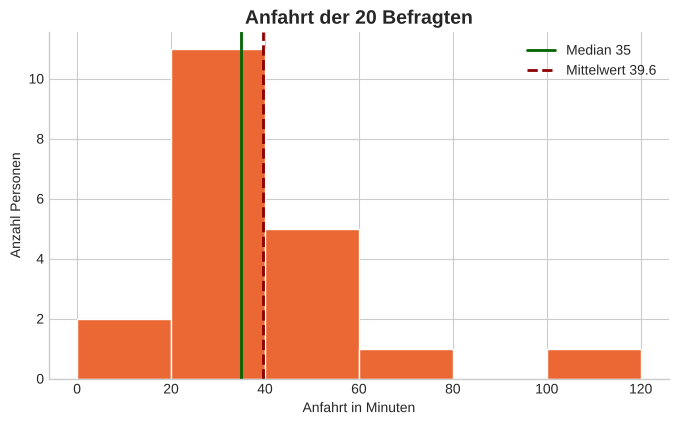

Gespeichert: anfahrt_histogramm.png


In [ ]:
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(grenzen[:-1], wie_skript.values, width=20, align="edge", color=ORANGE, edgecolor="white")
    ax.axvline(median, color="darkgreen", linewidth=2, label=f"Median {median:.0f}")
    ax.axvline(mittelwert, color="darkred", linewidth=2, linestyle="--", label=f"Mittelwert {mittelwert:.1f}")
    ax.set_xticks(grenzen)
    ax.set_title("Anfahrt der 20 Befragten", fontsize=14, fontweight="bold")
    ax.set_xlabel("Anfahrt in Minuten")
    ax.set_ylabel("Anzahl Personen")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend()

    fig.savefig("anfahrt_histogramm.png", dpi=150, bbox_inches="tight")   # zuerst speichern
    plt.show()                                                              # dann anzeigen

print("Gespeichert: anfahrt_histogramm.png")

---
## 18 – Bonus: Das Kreisdiagramm
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl behauptet:</b><br><br>„Für die Geschäftsführung nehme ich ein Kreisdiagramm. Das macht in jeder Präsentation etwas her.“</td></tr></table>

`ax.pie(werte, labels=...)` zeichnet einen Kreis. `autopct="%.0f %%"` schreibt die Prozente hinein.

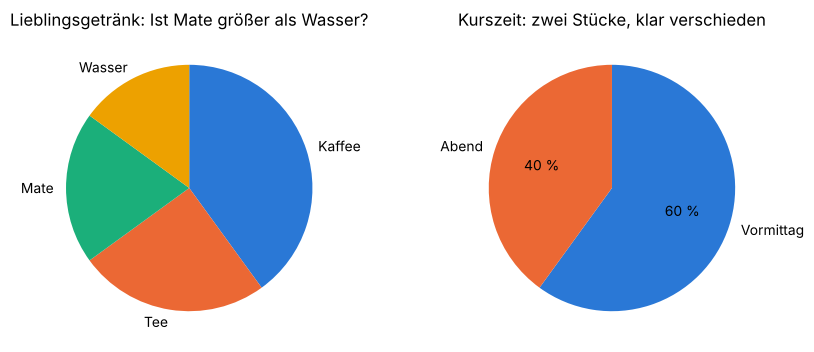

In [ ]:
fig, (links, rechts) = plt.subplots(1, 2, figsize=(10, 4))

links.pie(anzahl.values, labels=anzahl.index,
          colors=[GETRAENK_FARBEN[g] for g in anzahl.index],
          startangle=90, counterclock=False)
links.set_title("Lieblingsgetränk: Ist Mate größer als Wasser?")

rechts.pie(kurszeit.values, labels=kurszeit.index, colors=[BLAU, ORANGE],
           autopct="%.0f %%", startangle=90, counterclock=False)
rechts.set_title("Kurszeit: zwei Stücke, klar verschieden")

plt.show()

Links muss man genau hinsehen, ob Mate (20 %) größer ist als Wasser (15 %). Im Balkendiagramm sieht man es sofort. Winkel und Flächen schätzt das Auge schlechter als Längen.

Rechts passt der Kreis: Anteile an einem Ganzen, nur zwei Stücke, deutlich verschieden (60 % und 40 %).
<table><tr><td width="160"><img src="png%20Dateien/herr_bauchgefuehl_verdutzt.png" alt="Herr Bauchgefühl" width="150"></td><td><b>Herr Bauchgefühl stutzt:</b><br><br>„Dann bekommt die Geschäftsführung eben Balken. Hauptsache, sie sind sortiert.“</td></tr></table>

### Übung 5

Die Akademie schreibt einen Bericht über die Anfahrt. Du lieferst das Diagramm.

- **a)** Zeichne das Histogramm der Anfahrt mit Klassen von 20 Minuten, gezählt wie im Skript.
- **b)** Zeichne Median und Mittelwert als senkrechte Linien ein und zeige eine Legende.
- **c)** Verwende den Stil `"seaborn-v0_8-whitegrid"`, entferne den oberen und rechten Rahmen und gib dem Diagramm einen Titel.
- **d)** Speichere es als `anfahrt_bericht.png` mit `dpi=150`.
- **e)** Schreibe zwei Sätze für den Bericht: Wo liegen die meisten Anfahrtszeiten, und welche Form hat die Verteilung?

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c, d)

In [ ]:
# e)

# Block F – Weitere Übungen

| Übung | zu Block | Thema |
|---|---|---|
| 6 | B | Kompetenzen in Stellenanzeigen |
| 7 | B | Tool-Nachfrage: sortieren ohne `invert_yaxis` |
| 8 | B | UK-Charts 1964: die Plattenfirmen |
| 9 | C | Ist Mate vormittags dreimal so beliebt? |
| 10 | D | Reaktionszeiten |
| 11 | D | UK-Charts 1964: Wochen in den Charts und die Klassengrenzen |
| 12 | E | UK-Charts 1964: Form lesen und speichern |
| 13 | E | Prüfungsergebnisse im Berichtsstil |
| 14–16 | Zusatzblock | Getter & Setter (Abschnitt 19) |

---
### Übung 6 (zu Block B)

Eine Auswertung von 500 Stellenanzeigen für Datenanalysten:

| Kompetenz | Nennungen (%) |
|---|---|
| SQL | 89 |
| Python | 84 |
| Excel | 71 |
| Statistik | 63 |
| Power BI | 55 |
| Kommunikation | 48 |
| Git | 37 |

In [ ]:
kompetenzen = pd.Series([89, 84, 71, 63, 55, 48, 37],
                        index=["SQL", "Python", "Excel", "Statistik", "Power BI", "Kommunikation", "Git"])

- **a)** Sortiere die Series absteigend.
- **b)** Zeichne ein horizontales Balkendiagramm in Blau, häufigste Kompetenz oben. Titel: „Gefragte Kompetenzen in Datenanalyse-Stellenanzeigen (n=500)“, x-Achse: „Anteil Stellenanzeigen (%)“.
- **c)** Schreibe die Werte als „89%“ usw. rechts neben die Balken. Tipp: `ax.bar_label(balken, fmt="%d%%")`.
- **d)** Entferne den oberen und rechten Rahmen.

In [ ]:
# a)

In [ ]:
# b, c, d)

---
### Übung 7 (zu Block B)

Nachfrage nach Tools in Stellenanzeigen. Diesmal sind die Daten zwei Listen.

In [ ]:
skills    = ["Python", "SQL", "Excel", "Power BI", "Tableau", "R"]
nachfrage = [85, 78, 65, 52, 38, 25]

- **a)** Sortiere beide Listen gemeinsam **aufsteigend** nach der Nachfrage. Tipp: `zip()` verbindet die Listen paarweise, `sorted(..., key=lambda paar: paar[1])` sortiert nach der Zahl, `zip(*...)` trennt sie wieder.
- **b)** Zeichne ein horizontales Balkendiagramm **ohne** `invert_yaxis()`. Wo steht Python?
- **c)** Schreibe die Werte mit Prozentzeichen an die Balken, beschrifte die Achse und gib einen Titel.

In [ ]:
# a)

In [ ]:
# b, c)

---
### Übung 8 (zu Block B)

Die britischen Single-Charts vom Januar 1964. Die Spalte `Publisher` nennt die Plattenfirma, `WoC` (*weeks on chart*) die Anzahl der Wochen in den Charts.

In [ ]:
ordner = "csv & excel Dateien/"
charts = pd.read_csv(ordner + "UK-top40-1964-1-2.tsv", sep="\t")
charts.head()

,Pos,LW,Title,Artist,Publisher,Peak Pos,WoC
0,1,1,I WANT TO HOLD YOUR HAND,THE BEATLES,PARLOPHONE,1,5
1,2,6,GLAD ALL OVER,THE DAVE CLARK FIVE,COLUMBIA,2,7
2,3,2,SHE LOVES YOU,THE BEATLES,PARLOPHONE,1,19
3,4,3,YOU WERE MADE FOR ME,FREDDIE AND THE DREAMERS,COLUMBIA,3,9
4,5,9,TWENTY FOUR HOURS FROM TULSA,GENE PITNEY,UNITED ARTISTS,5,5


- **a)** Wie viele Titel und wie viele verschiedene Plattenfirmen gibt es?
- **b)** Zähle die Titel je Plattenfirma.
- **c)** Zeichne alle Plattenfirmen als horizontales Balkendiagramm, häufigste oben, mit Werten an den Balken.
- **d)** Oben stehen drei Firmen gleich lang. Was heißt das für die Frage „Welche Firma war die erfolgreichste?“
- **e)** Jemand will nur die „Top 10“ zeigen. Warum ist das hier ungünstig? Zeichne stattdessen alle Firmen mit mindestens 2 Titeln.

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c)

In [ ]:
# d)

In [ ]:
# e)

---
### Übung 9 (zu Block C)

In Übung 4c vom Vormittag stand die Frage: Im Vormittagskurs trinken 3 Personen am liebsten Mate, im Abendkurs nur 1. Ist Mate vormittags also dreimal so beliebt?

- **a)** Zeichne das gruppierte Balkendiagramm Kurszeit × Getränk. Lies die Mate-Balken ab.
- **b)** Berechne die Zeilenprozente und zeichne sie gestapelt auf 100 %. Lies die Mate-Anteile ab.
- **c)** Beantworte die Frage. Welches der beiden Diagramme passt zu ihr?

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c)

---
### Übung 10 (zu Block D)

Simulierte Reaktionszeiten aus einem Test mit 200 Messungen:

In [ ]:
np.random.seed(10)
reaktionszeiten = np.random.normal(loc=250, scale=40, size=200)   # in Millisekunden

- **a)** Zeichne ein Histogramm mit `bins=25`, `edgecolor="white"` und sinnvollen Achsenbeschriftungen.
- **b)** Zeichne den Mittelwert und den Median als senkrechte Linien ein, mit Legende.
- **c)** Welche Form hat die Verteilung? Vergleiche mit der Anfahrt.

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c)

---
### Übung 11 (zu Block D)

Wie viele Wochen waren die Titel schon in den Charts? Die Spalte `WoC` enthält **ganze Zahlen**. Genau da wird der Stolperstein aus Abschnitt 13 groß.

- **a)** Lass dir `describe()` für `WoC` ausgeben. Wie viele Klassen schlägt die Faustregel vor?
- **b)** Zähle mit den Grenzen `range(0, 21, 2)` einmal mit `ax.hist` und einmal mit `pd.cut`. Vergleiche die Zählungen.
- **c)** Lege die Grenzen auf halbe Werte: `np.arange(0.5, 21, 2)`, also 0,5 / 2,5 / 4,5 … Zähle wieder auf beide Arten. Was fällt auf, und warum?
- **d)** Zeichne `WoC` mit halben Grenzen und den Klassenbreiten 1, 2 und 5 nebeneinander. Welche Breite zeigt die Form am besten?

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c)

In [ ]:
# d)

---
### Übung 12 (zu Block E)

Bleib bei `WoC`.

- **a)** Zeichne das Histogramm mit Klassenbreite 2 und halben Grenzen. Zeichne Median und Mittelwert ein.
- **b)** Welcher Titel war am längsten in den Charts? Markiere ihn mit `ax.annotate`.
- **c)** Benenne die Form.
- **d)** Speichere das Diagramm im Stil `"seaborn-v0_8-whitegrid"` als `charts_woc.png`.

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c)

In [ ]:
# d)

---
### Übung 13 (zu Block E)

Prüfungsergebnisse von 8 Lernenden: `[72, 85, 63, 91, 78, 88, 70, 95]`.

- **a)** Zeichne ein Balkendiagramm mit den Namen `L1` bis `L8` auf der x-Achse.
- **b)** Zeichne den Klassendurchschnitt als waagerechte Linie ein (`ax.axhline(y, ...)`), mit Legende.
- **c)** Färbe Balken über dem Durchschnitt grün, die anderen rot.
- **d)** Verwende den Stil `"seaborn-v0_8-whitegrid"`, entferne den oberen und rechten Rahmen und speichere als `pruefungsergebnisse.png` mit `dpi=150`.

In [ ]:
# a)

In [ ]:
# b)

In [ ]:
# c, d)

---
## 19 – Zusatz: Getter und Setter

In Python ist (fast) alles ein **Objekt**. Ein Objekt hat

| Bestandteil | Bedeutung | Beispiel `ax` |
|---|---|---|
| Attribute | gespeicherte Eigenschaften | Titel, Achsenbeschriftung, Grenzen |
| Methoden | Aktionen | `bar()`, `set_title()`, `get_title()` |

Nach `fig, ax = plt.subplots()` ist `ax` ein Objekt vom Typ `Axes`.

| Begriff | englisch | was passiert | Schema |
|---|---|---|---|
| **Setter** | *to set* = setzen | Wert schreiben | `set_xyz(wert)` |
| **Getter** | *to get* = holen | Wert lesen | `get_xyz()` |

```
set_ → ich gebe dem Objekt etwas  →  „Ich setze den Titel.“
get_ → ich frage das Objekt etwas →  „Ich hole den Titel.“
```

Titel:          Lieblingsgetränk
y-Beschriftung: Anzahl Personen
y-Grenzen:      0.0 bis 8.4


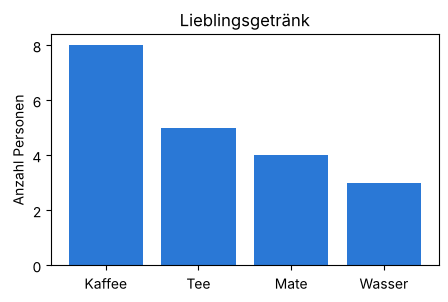

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(anzahl.index, anzahl.values, color=BLAU)

# SETTER: Eigenschaften setzen
ax.set_title("Lieblingsgetränk")
ax.set_ylabel("Anzahl Personen")

# GETTER: Eigenschaften auslesen
print("Titel:         ", ax.get_title())
print("y-Beschriftung:", ax.get_ylabel())
unten, oben = ax.get_ylim()
print("y-Grenzen:     ", unten, "bis", round(oben, 2))
plt.show()

**Warum nicht einfach `ax.title = "..."`?**

- **Kapselung:** Das Objekt schützt seine Daten. Von außen ändert man sie nur über Methoden.
- **Setter können mehr als speichern:** `ax.set_ylim(0, 10)` speichert zwei Zahlen, berechnet aber auch neue Achsenstriche und zeichnet das Diagramm neu.
- **Ein Muster für alles:** `Figure`, `Axes`, Text und Linien folgen demselben `set_`/`get_`-Schema.

| Setter | Getter | Wirkung |
|---|---|---|
| `ax.set_title(s)` | `ax.get_title()` | Titel |
| `ax.set_xlabel(s)` | `ax.get_xlabel()` | Beschriftung x-Achse |
| `ax.set_ylabel(s)` | `ax.get_ylabel()` | Beschriftung y-Achse |
| `ax.set_xlim(a, b)` | `ax.get_xlim()` | sichtbarer x-Bereich |
| `ax.set_ylim(a, b)` | `ax.get_ylim()` | sichtbarer y-Bereich |
| `ax.set_xticks([...])` | `ax.get_xticks()` | Achsenstriche x |
| `ax.set_facecolor(c)` | `ax.get_facecolor()` | Hintergrundfarbe |
| `fig.set_size_inches(b, h)` | `fig.get_size_inches()` | Größe der Figure |

> Im pyplot-Stil gibt es keine Getter. Auch das spricht für den OOP-Stil.

### Übung 14 (Zusatzblock)

- **a)** Zeichne die Haustiere als Balkendiagramm (Reihenfolge 0, 1, 2, 3).
- **b)** Setze mit Settern Titel, x- und y-Beschriftung sowie die y-Grenzen 0 bis 10.

In [ ]:
# a, b)

### Übung 15 (Zusatzblock)

- **a)** Lies im Diagramm aus Übung 14 alle gesetzten Eigenschaften mit Gettern aus und gib sie mit `print()` aus.

In [ ]:
# a)

### Übung 16 (Zusatzblock)

- **a)** Zeichne die Getränke als Balkendiagramm und schreibe mit `bar_label` die Werte über die Balken.
- **b)** Lies den y-Bereich mit `get_ylim()` aus und setze die obere Grenze auf das 1,2-Fache, damit die Zahlen Platz haben.

In [ ]:
# a, b)

---
## 20 – Zusammenfassung

| Aufgabe | Befehl |
|---|---|
| Figure und Diagramm anlegen | `fig, ax = plt.subplots(figsize=(6, 4))` |
| zwei Diagramme nebeneinander | `fig, (links, rechts) = plt.subplots(1, 2)` |
| Diagramm anzeigen | `plt.show()` |
| Titel und Achsen beschriften | `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()` |
| Balkendiagramm senkrecht | `ax.bar(anzahl.index, anzahl.values, color=BLAU)` |
| Balkendiagramm quer, größter oben | `ax.barh(...)` + `ax.invert_yaxis()` |
| Werte an die Balken | `balken = ax.bar(...)`, dann `ax.bar_label(balken)` |
| nominal: nach Häufigkeit | `value_counts()` |
| ordinal / gezählt: Reihenfolge behalten | `value_counts().sort_index()` |
| Anteile statt Anzahl | `value_counts(normalize=True) * 100` |
| Achse ab null (nicht verschieben!) | `ax.set_ylim(0, ...)` |
| gruppiertes Balkendiagramm | `kreuz.plot.bar(color=farben, rot=0)` |
| auf 100 % gestapelt | `anteile.plot.barh(stacked=True, color=farben)` |
| Legende | `ax.legend(title="...")` |
| Histogramm | `ax.hist(werte, bins=grenzen, edgecolor="white")` |
| Klassen „über a bis b“ wie im Skript | `pd.cut(...)` + `ax.bar(grenzen[:-1], ..., width=b, align="edge")` |
| ganze Zahlen ohne Grenzproblem | Grenzen auf halbe Werte: `np.arange(0.5, ..., b)` |
| Faustregel Klassenanzahl | `np.sqrt(len(werte))` |
| senkrechte / waagerechte Linie | `ax.axvline(x, label=...)`, `ax.axhline(y, ...)` |
| Pfeil mit Text | `ax.annotate(text, xy=..., xytext=..., arrowprops=dict(arrowstyle="->"))` |
| Rahmen oben und rechts entfernen | `ax.spines[["top", "right"]].set_visible(False)` |
| Stil für ein Diagramm | `with plt.style.context("seaborn-v0_8-whitegrid"):` |
| speichern (vor `plt.show()`!) | `fig.savefig("datei.png", dpi=150, bbox_inches="tight")` |
| Kreisdiagramm (Bonus) | `ax.pie(werte, labels=..., autopct="%.0f %%")` |
| Wert lesen / setzen | `ax.get_…()` / `ax.set_…()` |

---
*Material erstellt von Julia Brutskaya